# FitScan AI – ML Block: Calorie Burn Prediction

**Dataset:** Gym Members Exercise Dataset (Kaggle)  
**Goal:** Predict calories burned based on body metrics and workout parameters  
**Models:** Random Forest vs. XGBoost (2 iterations)  
**Integration:** The `Workout_Type` feature is later enriched by the CV block (exercise image classification)


## 1. Imports & Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import pickle
import warnings
warnings.filterwarnings('ignore')

print('Imports successful')

Imports successful


## 2. Load Data & First Overview

In [3]:
df = pd.read_csv('gym_members_exercise_tracking.csv')

print(f'Shape: {df.shape}')
print(f'\nColumns: {list(df.columns)}')
print(f'\nMissing values:')
print(df.isnull().sum())
df.head()

Shape: (973, 15)

Columns: ['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned', 'Workout_Type', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'BMI']

Missing values:
Age                              0
Gender                           0
Weight (kg)                      0
Height (m)                       0
Max_BPM                          0
Avg_BPM                          0
Resting_BPM                      0
Session_Duration (hours)         0
Calories_Burned                  0
Workout_Type                     0
Fat_Percentage                   0
Water_Intake (liters)            0
Workout_Frequency (days/week)    0
Experience_Level                 0
BMI                              0
dtype: int64


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


In [4]:
print('Statistical overview:')
df.describe()

Statistical overview:


,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
count,973.000000,973.000000,973.00000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000
mean,38.683453,73.854676,1.72258,179.883864,143.766701,62.223022,1.256423,905.422405,24.976773,2.626619,3.321686,1.809866,24.912127
std,12.180928,21.207500,0.12772,11.525686,14.345101,7.327060,0.343033,272.641516,6.259419,0.600172,0.913047,0.739693,6.660879
min,18.000000,40.000000,1.50000,160.000000,120.000000,50.000000,0.500000,303.000000,10.000000,1.500000,2.000000,1.000000,12.320000
25%,28.000000,58.100000,1.62000,170.000000,131.000000,56.000000,1.040000,720.000000,21.300000,2.200000,3.000000,1.000000,20.110000
50%,40.000000,70.000000,1.71000,180.000000,143.000000,62.000000,1.260000,893.000000,26.200000,2.600000,3.000000,2.000000,24.160000
75%,49.000000,86.000000,1.80000,190.000000,156.000000,68.000000,1.460000,1076.000000,29.300000,3.100000,4.000000,2.000000,28.560000
max,59.000000,129.900000,2.00000,199.000000,169.000000,74.000000,2.000000,1783.000000,35.000000,3.700000,5.000000,3.000000,49.840000


## 3. Exploratory Data Analysis (EDA)

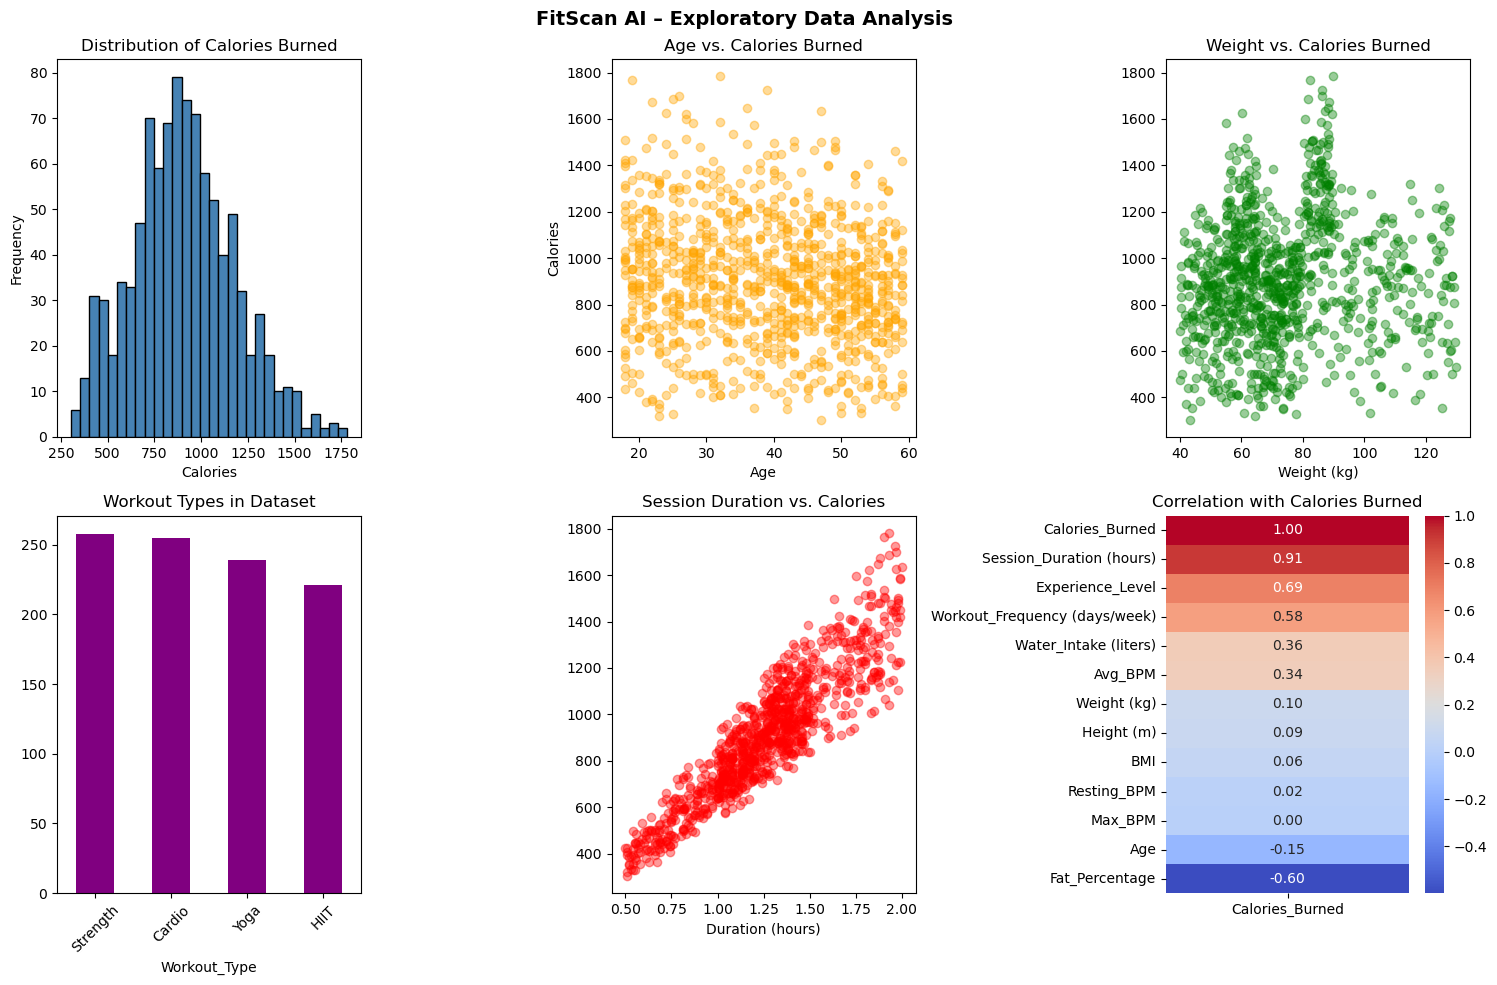

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('FitScan AI – Exploratory Data Analysis', fontsize=14, fontweight='bold')

# Distribution of calories burned
axes[0,0].hist(df['Calories_Burned'], bins=30, color='steelblue', edgecolor='black')
axes[0,0].set_title('Distribution of Calories Burned')
axes[0,0].set_xlabel('Calories')
axes[0,0].set_ylabel('Frequency')

# Age vs Calories
axes[0,1].scatter(df['Age'], df['Calories_Burned'], alpha=0.4, color='orange')
axes[0,1].set_title('Age vs. Calories Burned')
axes[0,1].set_xlabel('Age')
axes[0,1].set_ylabel('Calories')

# Weight vs Calories
axes[0,2].scatter(df['Weight (kg)'], df['Calories_Burned'], alpha=0.4, color='green')
axes[0,2].set_title('Weight vs. Calories Burned')
axes[0,2].set_xlabel('Weight (kg)')

# Workout types
df['Workout_Type'].value_counts().plot(kind='bar', ax=axes[1,0], color='purple')
axes[1,0].set_title('Workout Types in Dataset')
axes[1,0].tick_params(axis='x', rotation=45)

# Session Duration vs Calories
axes[1,1].scatter(df['Session_Duration (hours)'], df['Calories_Burned'], alpha=0.4, color='red')
axes[1,1].set_title('Session Duration vs. Calories')
axes[1,1].set_xlabel('Duration (hours)')

# Correlation heatmap
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(
    corr[['Calories_Burned']].sort_values('Calories_Burned', ascending=False),
    annot=True, ax=axes[1,2], cmap='coolwarm', fmt='.2f'
)
axes[1,2].set_title('Correlation with Calories Burned')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()


<Figure size 1000x500 with 0 Axes>

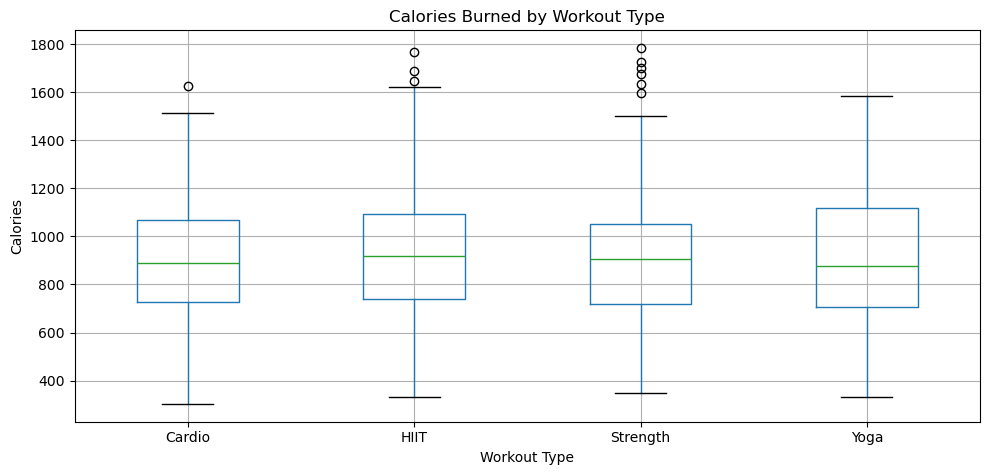


Average calories burned per workout type:
Workout_Type
HIIT        925.805430
Strength    910.697674
Yoga        903.188285
Cardio      884.513725
Name: Calories_Burned, dtype: float64


In [7]:
# Calories by workout type (Boxplot)
plt.figure(figsize=(10, 5))
df.boxplot(column='Calories_Burned', by='Workout_Type', figsize=(10,5))
plt.title('Calories Burned by Workout Type')
plt.suptitle('')
plt.xlabel('Workout Type')
plt.ylabel('Calories')
plt.tight_layout()
plt.savefig('calories_by_workout.png', dpi=150)
plt.show()

print('\nAverage calories burned per workout type:')
print(df.groupby('Workout_Type')['Calories_Burned'].mean().sort_values(ascending=False))

## 4. Preprocessing & Feature Engineering

In [9]:
df_clean = df.copy()

# Drop rows with missing values
df_clean = df_clean.dropna()
print(f'Dataset after cleaning: {df_clean.shape}')

# Encode categorical variables
le_workout = LabelEncoder()
le_gender = LabelEncoder()

df_clean['Workout_Type_encoded'] = le_workout.fit_transform(df_clean['Workout_Type'])
df_clean['Gender_encoded'] = le_gender.fit_transform(df_clean['Gender'])

print(f'\nWorkout classes: {list(le_workout.classes_)}')
print(f'Encoding mapping: {dict(zip(le_workout.classes_, le_workout.transform(le_workout.classes_)))}')

# Feature Engineering: compute BMI if not present
if 'BMI' not in df_clean.columns:
    df_clean['BMI'] = df_clean['Weight (kg)'] / (df_clean['Height (m)'] ** 2)
    print('\n BMI feature computed')
else:
    print('\n BMI already in dataset')

# New engineered feature: Heart Rate Intensity (Avg BPM / Max BPM)
# Captures how hard the user is working relative to their maximum capacity
# This feature is also used as a proxy until the CV block provides exercise_type
df_clean['Heart_Rate_Intensity'] = df_clean['Avg_BPM'] / df_clean['Max_BPM']
print(' New feature: Heart_Rate_Intensity (Avg_BPM / Max_BPM)')

# Define feature columns
feature_cols = [
    'Age', 'Weight (kg)', 'Height (m)', 'Session_Duration (hours)',
    'Workout_Type_encoded', 'Gender_encoded', 'Max_BPM', 'Avg_BPM',
    'Resting_BPM', 'Fat_Percentage', 'Water_Intake (liters)',
    'Workout_Frequency (days/week)', 'Experience_Level', 'BMI',
    'Heart_Rate_Intensity'
]

X = df_clean[feature_cols]
y = df_clean['Calories_Burned']

# Train / Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'\nTraining set: {X_train.shape}')
print(f'Test set:     {X_test.shape}')
print(f'Target (Calories): min={y.min():.0f}, max={y.max():.0f}, mean={y.mean():.0f}')

Dataset after cleaning: (973, 15)

Workout classes: ['Cardio', 'HIIT', 'Strength', 'Yoga']
Encoding mapping: {'Cardio': 0, 'HIIT': 1, 'Strength': 2, 'Yoga': 3}

 BMI already in dataset
 New feature: Heart_Rate_Intensity (Avg_BPM / Max_BPM)

Training set: (778, 15)
Test set:     (195, 15)
Target (Calories): min=303, max=1783, mean=905


## 5. Iteration 1 – Baseline Models (no hyperparameter tuning)

**Objective:** Establish a baseline performance with default settings.  
**Models:** Random Forest, XGBoost  
**Evaluation:** 5-Fold Cross-Validation R², Test R², MAE, RMSE

In [10]:
print('=' * 55)
print('ITERATION 1: Baseline models (default hyperparameters)')
print('=' * 55)
print('Objective: Establish baseline performance\n')

results = {}

# --- Model 1: Random Forest ---
rf1 = RandomForestRegressor(n_estimators=100, random_state=42)
rf1_cv = cross_val_score(rf1, X_train, y_train, cv=5, scoring='r2')
rf1.fit(X_train, y_train)
rf1_pred = rf1.predict(X_test)

results['RF_Iter1'] = {
    'CV R2': rf1_cv.mean(),
    'CV Std': rf1_cv.std(),
    'Test R2': r2_score(y_test, rf1_pred),
    'MAE': mean_absolute_error(y_test, rf1_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, rf1_pred))
}

print('Random Forest (baseline):')
print(f"  Hyperparameters: n_estimators=100 (default)")
print(f"  CV R2:   {results['RF_Iter1']['CV R2']:.4f} (+/- {results['RF_Iter1']['CV Std']:.4f})")
print(f"  Test R2: {results['RF_Iter1']['Test R2']:.4f}")
print(f"  MAE:     {results['RF_Iter1']['MAE']:.2f} calories")
print(f"  RMSE:    {results['RF_Iter1']['RMSE']:.2f} calories")

# --- Model 2: XGBoost ---
xgb1 = xgb.XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
xgb1_cv = cross_val_score(xgb1, X_train, y_train, cv=5, scoring='r2')
xgb1.fit(X_train, y_train)
xgb1_pred = xgb1.predict(X_test)

results['XGB_Iter1'] = {
    'CV R2': xgb1_cv.mean(),
    'CV Std': xgb1_cv.std(),
    'Test R2': r2_score(y_test, xgb1_pred),
    'MAE': mean_absolute_error(y_test, xgb1_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, xgb1_pred))
}

print('\nXGBoost (baseline):')
print(f"  Hyperparameters: n_estimators=100 (default)")
print(f"  CV R2:   {results['XGB_Iter1']['CV R2']:.4f} (+/- {results['XGB_Iter1']['CV Std']:.4f})")
print(f"  Test R2: {results['XGB_Iter1']['Test R2']:.4f}")
print(f"  MAE:     {results['XGB_Iter1']['MAE']:.2f} calories")
print(f"  RMSE:    {results['XGB_Iter1']['RMSE']:.2f} calories")

ITERATION 1: Baseline models (default hyperparameters)
Objective: Establish baseline performance

Random Forest (baseline):
  Hyperparameters: n_estimators=100 (default)
  CV R2:   0.9657 (+/- 0.0034)
  Test R2: 0.9713
  MAE:     37.60 calories
  RMSE:    48.90 calories

XGBoost (baseline):
  Hyperparameters: n_estimators=100 (default)
  CV R2:   0.9795 (+/- 0.0034)
  Test R2: 0.9822
  MAE:     27.48 calories
  RMSE:    38.53 calories


## 6. Iteration 2 – Tuned Models (with hyperparameter optimization)

**Objective:** Reduce overfitting and improve generalization over Iteration 1.  
**Changes:** Increased estimators, controlled depth, added regularization parameters.

In [11]:
print('=' * 55)
print('ITERATION 2: Tuned models (hyperparameter optimization)')
print('=' * 55)
print('Objective: Reduce overfitting, improve generalization\n')

# --- Model 1: Random Forest (tuned) ---
rf2 = RandomForestRegressor(
    n_estimators=200,       # more trees for stability
    max_depth=15,           # limit depth to prevent overfitting
    min_samples_split=5,    # require more samples to split
    min_samples_leaf=2,     # require more samples at leaves
    max_features='sqrt',    # feature subsampling
    random_state=42
)
rf2_cv = cross_val_score(rf2, X_train, y_train, cv=5, scoring='r2')
rf2.fit(X_train, y_train)
rf2_pred = rf2.predict(X_test)

results['RF_Iter2'] = {
    'CV R2': rf2_cv.mean(),
    'CV Std': rf2_cv.std(),
    'Test R2': r2_score(y_test, rf2_pred),
    'MAE': mean_absolute_error(y_test, rf2_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, rf2_pred))
}

print('Random Forest (tuned):')
print(f"  Hyperparameters: n_estimators=200, max_depth=15, min_samples_split=5, min_samples_leaf=2")
print(f"  CV R2:   {results['RF_Iter2']['CV R2']:.4f} (+/- {results['RF_Iter2']['CV Std']:.4f})")
print(f"  Test R2: {results['RF_Iter2']['Test R2']:.4f}")
print(f"  MAE:     {results['RF_Iter2']['MAE']:.2f} calories")
print(f"  RMSE:    {results['RF_Iter2']['RMSE']:.2f} calories")

# --- Model 2: XGBoost (tuned) ---
xgb2 = xgb.XGBRegressor(
    n_estimators=300,       # more boosting rounds
    max_depth=6,            # shallower trees to reduce variance
    learning_rate=0.05,     # lower learning rate for smoother convergence
    subsample=0.8,          # row subsampling
    colsample_bytree=0.8,   # column subsampling per tree
    min_child_weight=3,     # regularization via min samples in leaf
    random_state=42,
    verbosity=0
)
xgb2_cv = cross_val_score(xgb2, X_train, y_train, cv=5, scoring='r2')
xgb2.fit(X_train, y_train)
xgb2_pred = xgb2.predict(X_test)

results['XGB_Iter2'] = {
    'CV R2': xgb2_cv.mean(),
    'CV Std': xgb2_cv.std(),
    'Test R2': r2_score(y_test, xgb2_pred),
    'MAE': mean_absolute_error(y_test, xgb2_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, xgb2_pred))
}

print('\nXGBoost (tuned):')
print(f"  Hyperparameters: n_estimators=300, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8")
print(f"  CV R2:   {results['XGB_Iter2']['CV R2']:.4f} (+/- {results['XGB_Iter2']['CV Std']:.4f})")
print(f"  Test R2: {results['XGB_Iter2']['Test R2']:.4f}")
print(f"  MAE:     {results['XGB_Iter2']['MAE']:.2f} calories")
print(f"  RMSE:    {results['XGB_Iter2']['RMSE']:.2f} calories")

ITERATION 2: Tuned models (hyperparameter optimization)
Objective: Reduce overfitting, improve generalization

Random Forest (tuned):
  Hyperparameters: n_estimators=200, max_depth=15, min_samples_split=5, min_samples_leaf=2
  CV R2:   0.9129 (+/- 0.0084)
  Test R2: 0.9141
  MAE:     64.53 calories
  RMSE:    84.65 calories

XGBoost (tuned):
  Hyperparameters: n_estimators=300, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8
  CV R2:   0.9847 (+/- 0.0023)
  Test R2: 0.9873
  MAE:     24.09 calories
  RMSE:    32.59 calories


## 7. Model Comparison – Summary Table


=== MODEL COMPARISON ===
            CV R2  CV Std  Test R2      MAE     RMSE
RF_Iter1   0.9657  0.0034   0.9713  37.6025  48.9000
XGB_Iter1  0.9795  0.0034   0.9822  27.4763  38.5344
RF_Iter2   0.9129  0.0084   0.9141  64.5262  84.6502
XGB_Iter2  0.9847  0.0023   0.9873  24.0897  32.5879


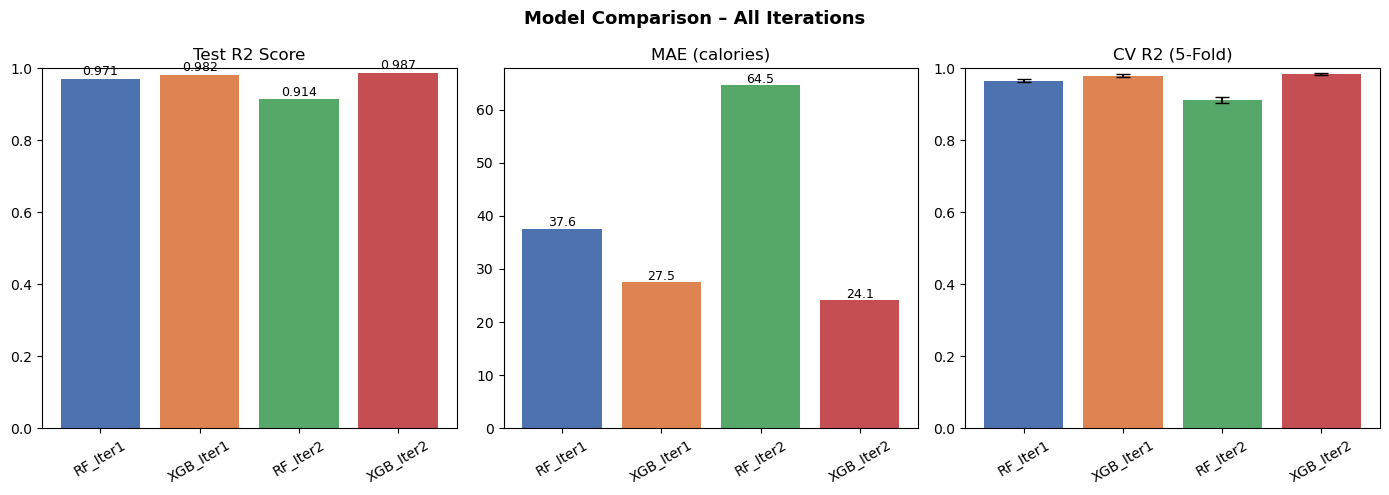

Comparison plot saved: model_comparison.png


In [13]:
summary = pd.DataFrame(results).T
summary = summary.round(4)
print('\n=== MODEL COMPARISON ===')
print(summary.to_string())

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Model Comparison – All Iterations', fontsize=13, fontweight='bold')

models = list(results.keys())
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

# R2 comparison
r2_vals = [results[m]['Test R2'] for m in models]
axes[0].bar(models, r2_vals, color=colors)
axes[0].set_title('Test R2 Score')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(r2_vals):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

# MAE comparison
mae_vals = [results[m]['MAE'] for m in models]
axes[1].bar(models, mae_vals, color=colors)
axes[1].set_title('MAE (calories)')
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(mae_vals):
    axes[1].text(i, v + 0.5, f'{v:.1f}', ha='center', fontsize=9)

# CV R2 comparison
cv_vals = [results[m]['CV R2'] for m in models]
cv_std  = [results[m]['CV Std'] for m in models]
axes[2].bar(models, cv_vals, yerr=cv_std, color=colors, capsize=5)
axes[2].set_title('CV R2 (5-Fold)')
axes[2].set_ylim(0, 1)
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Comparison plot saved: model_comparison.png')

## 8. Feature Importance & Error Analysis

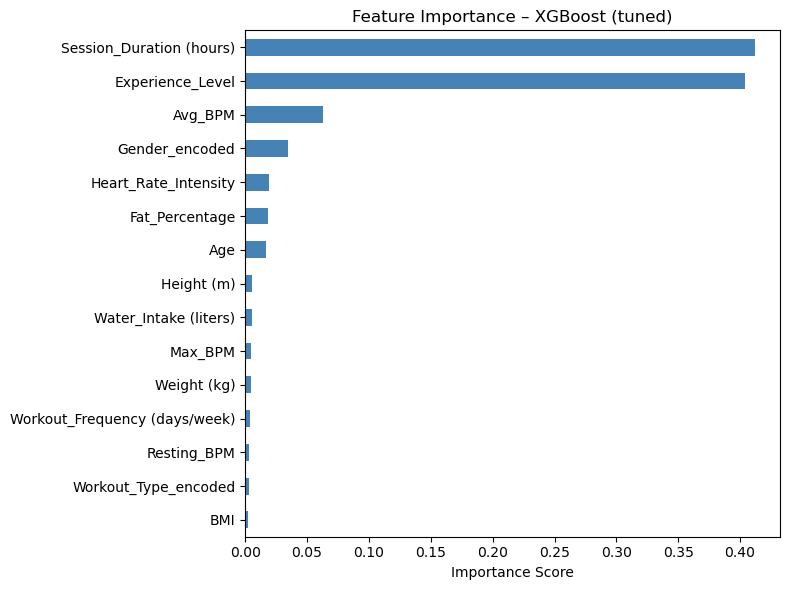

Top 5 most important features:
Heart_Rate_Intensity        0.018955
Gender_encoded              0.034378
Avg_BPM                     0.062806
Experience_Level            0.403645
Session_Duration (hours)    0.411654
dtype: float32


In [14]:
# Feature Importance (best model = XGBoost Iter2)
best_model = xgb2
feat_imp = pd.Series(best_model.feature_importances_, index=feature_cols)
feat_imp_sorted = feat_imp.sort_values(ascending=True)

plt.figure(figsize=(8, 6))
feat_imp_sorted.plot(kind='barh', color='steelblue')
plt.title('Feature Importance – XGBoost (tuned)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print('Top 5 most important features:')
print(feat_imp_sorted.tail(5))

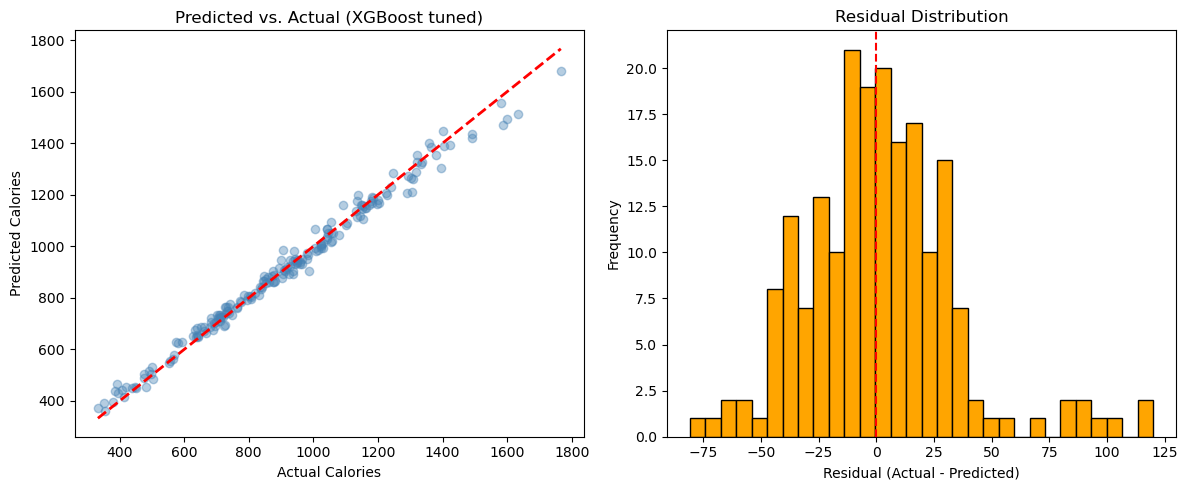

Mean error (bias): 0.94 calories
Std of residuals:  32.66 calories


In [15]:
# Error Analysis: Predicted vs Actual
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scatter: Predicted vs Actual
axes[0].scatter(y_test, xgb2_pred, alpha=0.4, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Calories')
axes[0].set_ylabel('Predicted Calories')
axes[0].set_title('Predicted vs. Actual (XGBoost tuned)')

# Residuals
residuals = y_test - xgb2_pred
axes[1].hist(residuals, bins=30, color='orange', edgecolor='black')
axes[1].axvline(x=0, color='red', linestyle='--')
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.savefig('error_analysis.png', dpi=150)
plt.show()

print(f'Mean error (bias): {residuals.mean():.2f} calories')
print(f'Std of residuals:  {residuals.std():.2f} calories')

## 9. Save Best Model

In [16]:
# Best model = XGBoost Iteration 2
best_model = xgb2

with open('calories_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('label_encoder_workout.pkl', 'wb') as f:
    pickle.dump(le_workout, f)

with open('label_encoder_gender.pkl', 'wb') as f:
    pickle.dump(le_gender, f)

with open('feature_cols.pkl', 'wb') as f:
    pickle.dump(feature_cols, f)

print('Model saved:          calories_model.pkl')
print('Workout encoder saved: label_encoder_workout.pkl')
print('Gender encoder saved:  label_encoder_gender.pkl')
print('Feature list saved:    feature_cols.pkl')
print(f'\nWorkout classes (used in app.py): {list(le_workout.classes_)}')
print(f'Encoding mapping: {dict(zip(le_workout.classes_, le_workout.transform(le_workout.classes_)))}')

Model saved:          calories_model.pkl
Workout encoder saved: label_encoder_workout.pkl
Gender encoder saved:  label_encoder_gender.pkl
Feature list saved:    feature_cols.pkl

Workout classes (used in app.py): ['Cardio', 'HIIT', 'Strength', 'Yoga']
Encoding mapping: {'Cardio': 0, 'HIIT': 1, 'Strength': 2, 'Yoga': 3}


## 10. Prediction Function (used in app.py)

This function will be imported by `app.py`. The `workout_type` parameter is provided by the **CV block** (image classification result), enabling the integration between blocks.

In [18]:
def predict_calories(age, weight_kg, height_m, session_duration_h,
                     workout_type, gender, max_bpm, avg_bpm, resting_bpm,
                     fat_percentage, water_intake, workout_frequency,
                     experience_level):
    """
    Predict calories burned for a given workout session.

    Parameters:
        workout_type (str): Exercise type, e.g. 'Cardio', 'Strength', 'Yoga', 'HIIT'
                            Provided by the CV block (image classification).
        gender (str):       'Male' or 'Female'

    Returns:
        float: Predicted calories burned
    """
    workout_enc = le_workout.transform([workout_type])[0]
    gender_enc  = le_gender.transform([gender])[0]
    bmi = weight_kg / (height_m ** 2)
    heart_rate_intensity = avg_bpm / max_bpm if max_bpm > 0 else 0.8

    features = pd.DataFrame([{
        'Age': age,
        'Weight (kg)': weight_kg,
        'Height (m)': height_m,
        'Session_Duration (hours)': session_duration_h,
        'Workout_Type_encoded': workout_enc,
        'Gender_encoded': gender_enc,
        'Max_BPM': max_bpm,
        'Avg_BPM': avg_bpm,
        'Resting_BPM': resting_bpm,
        'Fat_Percentage': fat_percentage,
        'Water_Intake (liters)': water_intake,
        'Workout_Frequency (days/week)': workout_frequency,
        'Experience_Level': experience_level,
        'BMI': bmi,
        'Heart_Rate_Intensity': heart_rate_intensity
    }])

    prediction = best_model.predict(features)[0]
    return round(prediction, 0)


# Quick test
test_result = predict_calories(
    age=28, weight_kg=75, height_m=1.78,
    session_duration_h=1.0, workout_type='Cardio',
    gender='Male', max_bpm=185, avg_bpm=145,
    resting_bpm=65, fat_percentage=18.0,
    water_intake=2.5, workout_frequency=3,
    experience_level=2
)
print(f'Test prediction: {test_result:.0f} calories burned')

Test prediction: 834 calories burned
